# P1 · What a tensor contains

Unit 0 foundations for the current Tiny Transformer and the later Phyll course. Basic Python variables, loops and functions are assumed.

Download and open this notebook in Jupyter, or choose **File → Upload notebook** in Google Colab. All examples and the required helper code are included. No account key, private repository, GPU or dataset download is needed.

Examples are **illustrative**, executed with Python and PyTorch. Newly constructed model weights are explicitly untrained. Run from a fresh kernel in order. Each exercise can run before you fill it in; open its folded solution afterward.

The `show` helper prints named intermediate results. It is course code, not a built-in Python or PyTorch function.

In [1]:
import sys, math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.set_num_threads(1)
torch.manual_seed(7)
print("Python", sys.version.split()[0], "· PyTorch", torch.__version__, "· CPU")
print("Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.")


Python 3.12.3 · PyTorch 2.10.0+cpu · CPU
Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.


Publication destination: the [public course labs repository](https://github.com/gkiri/tiny_repo). This notebook includes its own examples and can run before that mirror is published.

In [2]:
#@title Display helper: print and draw executed values { display-mode: "form" }
"""Small display helper embedded verbatim in independent notebooks; traces record real executions."""
import json
import math

FRAMES = []


def plain(value):
    if hasattr(value, "detach"):
        return plain(value.detach().cpu().tolist())
    if isinstance(value, dict):
        return {str(k): plain(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [plain(v) for v in value]
    if isinstance(value, float) and not math.isfinite(value):
        return str(value)
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def show(label, value):
    """Print and snapshot an intermediate. This helper is course code, not a PyTorch API."""
    frame = {"label": label, "value": plain(value)}
    if hasattr(value, "shape"):
        frame.update(shape=list(value.shape), dtype=str(value.dtype), device=str(value.device))
    FRAMES.append(frame)
    print(label + ":", json.dumps(frame["value"], ensure_ascii=False))
    if "shape" in frame:
        print("  shape", frame["shape"], "·", frame["dtype"], "·", frame["device"])


def draw_trace():
    """A portable SVG trace diagram; requires only the notebook's existing IPython display."""
    import html
    from IPython.display import SVG, display
    height = 82 * len(FRAMES) + 12
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 720 {height}" role="img" aria-label="Executed intermediate values">']
    for i, frame in enumerate(FRAMES):
        y = 8 + 82*i
        value = json.dumps(frame["value"], ensure_ascii=False)
        if len(value) > 91:
            value = value[:88] + "…"
        parts += [f'<rect x="4" y="{y}" width="708" height="68" rx="10" fill="#f4f8ef" stroke="#779861"/>',
                  f'<text x="20" y="{y+25}" font-size="15" font-family="sans-serif" fill="#31524b">{i+1}. {html.escape(frame["label"])}</text>',
                  f'<text x="20" y="{y+48}" font-size="12" font-family="monospace" fill="#252a33">{html.escape(value)}</text>']
        if i + 1 < len(FRAMES):
            parts.append(f'<path d="M360 {y+68} v14" stroke="#7042a6" stroke-width="2"/>')
    display(SVG("".join(parts) + "</svg>"))

## P1.1 · What a tensor contains

Inspect values, shape, dtype and device together: each is part of the next operation’s input contract.

**Prerequisites:** Basic variables, loops and functions.

**Predict:** Does converting IDs to float create embeddings?

**Mental model:** The same printed numbers can participate in different operations. An integer ID names an entry, while a floating-point feature is a value a layer calculates with.

<a data-compat-cell="p1-tensors"></a>

### P1.1.1 · Understand the need

The same printed numbers can participate in different operations. An integer ID names an entry, while a floating-point feature is a value a layer calculates with.

A tensor carries a shape, a data type and a device as well as its values. A valid operation must satisfy all those contracts.

A Boolean tensor records a yes-or-no result at each position. Such comparisons become masks inside attention and evaluation code.

Converting integer IDs to floating point changes their representation, not their meaning. Casting IDs is not an embedding lookup.

Begin every unfamiliar tensor operation by inspecting its input. The resulting error message is easier to interpret when these properties are visible.

### P1.1.2 · Follow the values

Create the integer sequence two, zero and one. It has one axis containing three entries on the CPU.

Convert those values to floating point. The values remain two, zero and one; the dtype changes to the selected floating-point format.

Compare the IDs with zero. The comparison returns true, false and true, preserving the original shape.

Inspect shape, dtype, device and the total element count together. Shape describes arrangement, while element count is the product of axis lengths.

Extract one scalar with item and the full sequence with tolist. These return ordinary Python values for inspection outside tensor calculations.

In [3]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
ids = torch.tensor([2, 0, 1], dtype=torch.long)
show("Integer IDs", ids)
features = ids.to(torch.float64 if change else torch.float32)
show("Floating-point values", features)
show("Boolean comparison", ids > 0)
show("Properties", {"shape": list(ids.shape), "dtype": str(ids.dtype), "device": str(ids.device), "elements": ids.numel()})
show("Tensor to Python", {"one item": ids[0].item(), "all items": ids.tolist()})

Integer IDs: [2, 0, 1]
  shape [3] · torch.int64 · cpu
Floating-point values: [2.0, 0.0, 1.0]
  shape [3] · torch.float32 · cpu
Boolean comparison: [true, false, true]
  shape [3] · torch.bool · cpu
Properties: {"shape": [3], "dtype": "torch.int64", "device": "cpu", "elements": 3}
Tensor to Python: {"one item": 2, "all items": [2, 0, 1]}


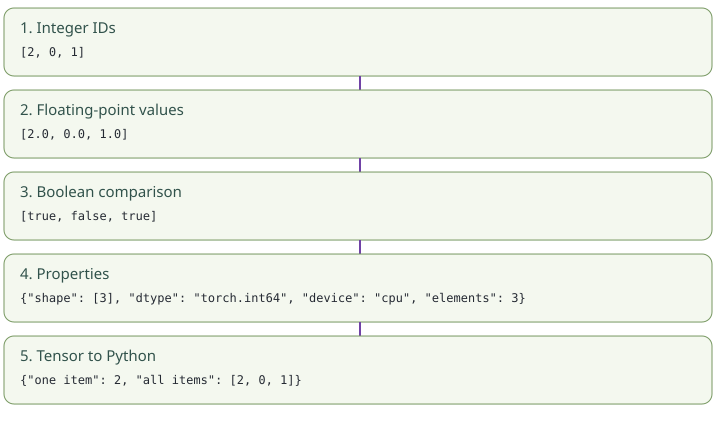

In [4]:
draw_trace()

### P1.1.3 · Read and run the code

Torch tensor constructs values from Python data. Specify long for the ID examples so an implicit dtype choice cannot obscure their role.

The to method can change a tensor's data type or device. Use the returned tensor rather than assuming every conversion mutates the original object.

A comparison operates element by element and produces a Boolean tensor. Multiple truth values cannot be used as one Python condition without an explicit reduction.

Shape is an attribute; numel is a method and needs parentheses. Item also needs parentheses and requires exactly one element.

Create zeros, ones, an ordered range, or normal random samples with the matching tensor constructors. Inspect their dtype and device too, especially when creating a new tensor beside an existing one.

### Change one thing

**Use float64 instead of float32**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [5]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
ids = torch.tensor([2, 0, 1], dtype=torch.long)
show("Integer IDs", ids)
features = ids.to(torch.float64 if change else torch.float32)
show("Floating-point values", features)
show("Boolean comparison", ids > 0)
show("Properties", {"shape": list(ids.shape), "dtype": str(ids.dtype), "device": str(ids.device), "elements": ids.numel()})
show("Tensor to Python", {"one item": ids[0].item(), "all items": ids.tolist()})

Integer IDs: [2, 0, 1]
  shape [3] · torch.int64 · cpu
Floating-point values: [2.0, 0.0, 1.0]
  shape [3] · torch.float64 · cpu
Boolean comparison: [true, false, true]
  shape [3] · torch.bool · cpu
Properties: {"shape": [3], "dtype": "torch.int64", "device": "cpu", "elements": 3}
Tensor to Python: {"one item": 2, "all items": [2, 0, 1]}


### A useful distinction

Casting an ID to float does not turn it into a learned embedding.

### ✋ Your turn

Create a long tensor [1,2,3] and put its element count in answer.

In [6]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 3, 'Casting an ID to float does not turn it into a learned embedding.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [7]:
#@title Show a solution { display-mode: "form" }
answer = torch.tensor([1, 2, 3], dtype=torch.long).numel()

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 3, 'Casting an ID to float does not turn it into a learned embedding.'
    print("✓ right:", answer)

✓ right: 3


### P1.1.4 · Find it in the model

Token inputs arrive as integer tensors. Embedding tables and intermediate model features use floating-point tensors, while causal permissions can use Boolean masks.

Position indices must be created on the same device as the input when the embedding lookup runs there. The model passes the input's device to arange.

Training gradients apply to appropriate floating-point parameters, not to the integer labels naming characters. The gradient chapter will make that distinction concrete.

CPU execution is enough for these notebooks. Device transfers become important for larger models, but they do not change what the axes mean.

Next, read those axes from scalars to the four-dimensional tensors used by attention.

```python
positions = torch.arange(T, device=idx.device)
x = self.tok_emb(idx) + self.pos_emb(positions)
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** Does converting IDs to float create embeddings?

<details><summary>Check your explanation</summary>

No; lookup uses a separate learned table. Casting an ID to float does not turn it into a learned embedding.

</details>